># TMDB Project: Spark Implementation

This notebook implements the TMDB movie data analysis pipeline using Apache Spark (PySpark). 
It covers:
1. **Data Extraction**: Fetching data from TMDB API.
2. **Data Cleaning**: Preprocessing and transforming data using Spark.
3. **Analysis**: Computing KPIs and running queries.
4. **Visualization**: Generating charts.

## Setup and Initialization

In [1]:
import os
import json

os.environ["PYSPARK_PYTHON"] = r"D:\AmaliTech\Moodle labs\DEM05\Lab 1\BySpark\venv\Scripts\python.exe"
os.environ["PYSPARK_DRIVER_PYTHON"] = r"D:\AmaliTech\Moodle labs\DEM05\Lab 1\BySpark\venv\Scripts\python.exe"

from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, FloatType

# Load environment variables
load_dotenv('../.env')
api_key = os.getenv("api_key")

if not api_key:
    print("WARNING: API key not found. Please check .env file.")
else:
    print("API Key loaded.")


API Key loaded.


Initialize Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("TMDB_Analysis_Notebook") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark Session Initialized.")

Spark Session Initialized.


>## Phase 1: Data Extraction: From the TMDB API
Fetch movie data from the TMDB API.

In [3]:
from extraction.tmdb_api import fetch_movie_data

movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 
             99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]
             
# Fetch data
raw_data = fetch_movie_data(api_key, movie_ids)

# Create Initial DataFrame
# df_raw = spark.createDataFrame(raw_data)

# FIX: Convert to JSON strings first, then read as JSON. 
# This helps Spark correctly infer Structs (objects) instead of Maps in creating the DataFrame.
json_rdd = spark.sparkContext.parallelize([json.dumps(r) for r in raw_data])
df_raw = spark.read.json(json_rdd)

Starting extraction for 19 movies...
Error fetching movie ID 0: 404
Successfully fetched details for movie info: 597
Successfully fetched details for movie info: 12445
Successfully fetched details for movie info: 19995
Successfully fetched details for movie info: 24428
Successfully fetched details for movie info: 99861
Successfully fetched details for movie info: 109445
Successfully fetched details for movie info: 135397
Successfully fetched details for movie info: 140607
Successfully fetched details for movie info: 168259
Successfully fetched details for movie info: 181808
Successfully fetched details for movie info: 260513
Successfully fetched details for movie info: 284054
Successfully fetched details for movie info: 299534
Successfully fetched details for movie info: 299536
Successfully fetched details for movie info: 321612
Successfully fetched details for movie info: 330457
Successfully fetched details for movie info: 351286
Successfully fetched details for movie info: 420818
Ext

In [4]:
df_raw.show(3)

+-----+--------------------+---------------------+---------+--------------------+--------------------+--------------------+-----+---------+--------------------+--------------+-----------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+--------------------+------------+----------+-------+--------------------+--------------------+--------+--------------------+--------------------+-----+--------------------+------------+----------+
|adult|       backdrop_path|belongs_to_collection|   budget|             credits|              genres|            homepage|   id|  imdb_id|            keywords|origin_country|original_language|      original_title|            overview|popularity|         poster_path|production_companies|production_countries|     recommendations|release_date|   revenue|runtime|             similar|    spoken_languages|  status|             tagline|               title|video|              videos|vote_averag

In [5]:
df_raw.printSchema()

root
 |-- adult: boolean (nullable = true)
 |-- backdrop_path: string (nullable = true)
 |-- belongs_to_collection: struct (nullable = true)
 |    |-- backdrop_path: string (nullable = true)
 |    |-- id: long (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- poster_path: string (nullable = true)
 |-- budget: long (nullable = true)
 |-- credits: struct (nullable = true)
 |    |-- cast: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- adult: boolean (nullable = true)
 |    |    |    |-- cast_id: long (nullable = true)
 |    |    |    |-- character: string (nullable = true)
 |    |    |    |-- credit_id: string (nullable = true)
 |    |    |    |-- gender: long (nullable = true)
 |    |    |    |-- id: long (nullable = true)
 |    |    |    |-- known_for_department: string (nullable = true)
 |    |    |    |-- name: string (nullable = true)
 |    |    |    |-- order: long (nullable = true)
 |    |    |    |-- original_nam

>## Phase 2: Data Cleaning
Process the raw data: remove duplicates, handle missing values, correct data types.

remove irrevant columns

In [6]:
# 1. Drop irrelevant columns
columns_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']
df_dropped = df_raw.drop(*columns_to_drop)

Evaluate, Extract and clean key data points from JSON-like columns `belongs_to_collection`, `genres`, `production_countries`, `production_companies`, `spoken_languages`.



In [7]:
json_like = [
    'belongs_to_collection',
    'production_countries',
    'production_companies',
    'genres',
    'spoken_languages'
]

df_raw.select(*json_like).show(10, truncate=False)


+---------------------------------------------------------------------------------------------------------------+------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------+
|belongs_to_collection                                                                                          |production_countries                                  |production_companies                                                                                                                                                                                      

In [8]:
for col_name in ["production_companies", "production_countries", "spoken_languages", "genres"]:
    if col_name in df_dropped.columns:
        df_dropped = df_dropped.withColumn(
            col_name,
            F.concat_ws("|", F.expr(f"transform({col_name}, x -> x.name)"))
        )

# Struct column handled once
if "belongs_to_collection" in df_dropped.columns:
    df_dropped = df_dropped.withColumn(
        "collection_name",
        F.col("belongs_to_collection.name")
    )


Inspect extracted columns using value_counts() to identify anomalies

In [9]:
cols_to_check = [
    "genres",
    "spoken_languages",
    "production_countries",
    "production_companies",
    "collection_name"
]

for c in cols_to_check:
    if c in df_dropped.columns:
        print(f"\n Value counts for {c} column")
        (
            df_dropped
            .groupBy(c)
            .count()
            .orderBy(F.desc("count"))
            .show(10, truncate=False)
        )



 Value counts for genres column
+-----------------------------------------+-----+
|genres                                   |count|
+-----------------------------------------+-----+
|Adventure|Action|Science Fiction         |3    |
|Action|Adventure|Science Fiction         |2    |
|Action|Adventure|Science Fiction|Thriller|2    |
|Drama|Romance                            |1    |
|Adventure|Fantasy                        |1    |
|Action|Adventure|Fantasy|Science Fiction |1    |
|Science Fiction|Action|Adventure         |1    |
|Animation|Family|Adventure|Fantasy       |1    |
|Action|Crime|Thriller                    |1    |
|Action|Adventure|Animation|Family        |1    |
+-----------------------------------------+-----+
only showing top 10 rows


 Value counts for spoken_languages column
+-------------------------------------------------+-----+
|spoken_languages                                 |count|
+-------------------------------------------------+-----+
|English                

### Handling Missing & Incorrect Data

In [10]:
df_clean = df_dropped.withColumn("budget", F.col("budget").cast(FloatType())) \
                        .withColumn("revenue", F.col("revenue").cast(FloatType())) \
                        .withColumn("vote_count", F.col("vote_count").cast(IntegerType())) \
                        .withColumn("vote_average", F.col("vote_average").cast(FloatType())) \
                        .withColumn("popularity", F.col("popularity").cast(FloatType())) \
                        .withColumn("runtime", F.col("runtime").cast(IntegerType()))


In [11]:
# Release Date
df_clean = df_clean.withColumn("release_date", F.to_date(F.col("release_date"), "yyyy-MM-dd"))

In [12]:
# Replace 0 with NaN (Null in Spark usually serves this purpose better for SQL ops, but we can use NaN for floats)
# Requirement: "Budget/Revenue/Runtime = 0 -> Replace with NaN"
# Note: Spark SQL does support 'NaN' for Double/Float.
df_clean = df_clean.withColumn("budget", F.when(F.col("budget") == 0, F.lit(None)).otherwise(F.col("budget")))
df_clean = df_clean.withColumn("revenue", F.when(F.col("revenue") == 0, F.lit(None)).otherwise(F.col("revenue")))
df_clean = df_clean.withColumn("runtime", F.when(F.col("runtime") == 0, F.lit(None)).otherwise(F.col("runtime")))


In [13]:
# Convert to Musd
df_clean = df_clean.withColumn("budget_musd", F.col("budget") / 1000000)
df_clean = df_clean.withColumn("revenue_musd", F.col("revenue") / 1000000)


In [14]:
# 4. Filter 'Released' movies
if 'status' in df_clean.columns:
    df_clean = df_clean.filter(F.col("status") == "Released")
    # Reuse df_clean to drop status after filter
    df_clean = df_clean.drop("status")


In [15]:
# 5. Remove duplicates and rows with unknown ID/Title
df_clean = df_clean.dropDuplicates(['id'])
df_clean = df_clean.filter(F.col("id").isNotNull() & F.col("title").isNotNull())

6. Keep rows with `at least 10 non-null` columns (using a check of how many columns are not null)
This is expensive in Spark, but we can do it with an expression

In [16]:
cols_to_check = df_clean.columns
# Create an expression that sums up 1 for every NOT NULL column
non_null_count_expr = sum(F.when(F.col(c).isNotNull(), 1).otherwise(0) for c in cols_to_check)
df_clean = df_clean.withColumn("non_null_count", non_null_count_expr)
df_clean = df_clean.filter(F.col("non_null_count") >= 10)
df_clean = df_clean.drop("non_null_count")

In [17]:
# Check if all columns in cols_order exist in df_clean as required
cols_order = ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection', 'original_language', 
    'budget_musd', 'revenue_musd', 'production_companies', 'production_countries', 'vote_count', 
    'vote_average', 'popularity', 'runtime', 'overview', 'spoken_languages', 'poster_path', 
    'cast', 'cast_size', 'director', 'crew_size']

for c in cols_order:
    if c not in df_clean.columns:
        print(c)

cast
cast_size
director
crew_size


In [18]:
# Extract Cast and Crew details
if 'credits' in df_dropped.columns:
    # Cast Names
    df_clean = df_clean.withColumn("cast", F.expr("transform(credits.cast, x -> x.name)"))
    df_clean = df_clean.withColumn("cast", F.concat_ws("|", "cast"))
    
    # Cast Size
    df_clean = df_clean.withColumn("cast_size", F.size(F.col("credits.cast")))
    
    # Director (First crew member with job='Director')
    df_clean = df_clean.withColumn("director", F.expr("filter(credits.crew, x -> x.job = 'Director')[0].name"))
    
    # Crew Size
    df_clean = df_clean.withColumn("crew_size", F.size(F.col("credits.crew")))

In [19]:
# 7. Reorder columns as specified in the instructions
existing_cols = [c for c in cols_order if c in df_clean.columns]
df_clean = df_clean.select(*existing_cols)

print("Data cleaning completed.")

Data cleaning completed.


Below are step mentioned above 🔝 but below are alternative you ⬇️

In [20]:
# from cleaning.preprocessor import clean_dataframe
# df_clean = clean_dataframe(df_raw)
# df_clean.printSchema()

>## Phase 3: Analysis & KPIs
Perform aggregations and ranking.

In [21]:
from analysis.kpi_calculations import (
    get_best_worst_movies, 
    search_queries, 
    compare_franchises, 
    analyze_directors
)
# df = spark.read.csv('data\cleaned_csv\part-00000-f080cb58-d9b0-489c-a453-1a08676895bb-c000.csv', header=True, inferSchema=True)

Identify the Best/Worst Performing Movies

Filter and rank movies based on:
- Revenue

In [22]:
rankings = get_best_worst_movies(df_clean)

In [23]:
# 1. Best & Worst Movies
print("\nTop 5 by Revenue")
rankings["best_revenue"].select("title", "revenue_musd", "budget_musd").show(truncate=False)


Top 5 by Revenue
+----------------------------+------------+-----------+
|title                       |revenue_musd|budget_musd|
+----------------------------+------------+-----------+
|Avatar                      |2923.706112 |237.0      |
|Avengers: Endgame           |2799.439104 |356.0      |
|Titanic                     |2264.162304 |200.0      |
|Star Wars: The Force Awakens|2068.223616 |245.0      |
|Avengers: Infinity War      |2052.414976 |300.0      |
+----------------------------+------------+-----------+



- Budget

In [24]:
rankings['best_budget'].select(['title', 'budget_musd', 'revenue_musd', 'profit_musd']).show(truncate=False)

+----------------------------+-----------+------------+------------------+
|title                       |budget_musd|revenue_musd|profit_musd       |
+----------------------------+-----------+------------+------------------+
|Avengers: Endgame           |356.0      |2799.439104 |2443.439104       |
|Star Wars: The Last Jedi    |300.0      |1332.69888  |1032.69888        |
|Avengers: Infinity War      |300.0      |2052.414976 |1752.414976       |
|The Lion King               |260.0      |1662.020864 |1402.020864       |
|Star Wars: The Force Awakens|245.0      |2068.223616 |1823.2236160000002|
+----------------------------+-----------+------------+------------------+



- Profitability Analysis

In [25]:
print('Top five movies by profit')
rankings['best_profit'].select(['title', 'profit_musd', 'budget_musd', 'revenue_musd']).show(truncate=False)

print('Bottom five movies by profit')
rankings['worst_profit'].select(['title', 'profit_musd', 'budget_musd', 'revenue_musd']).show(truncate=False)

Top five movies by profit
+----------------------------+------------------+-----------+------------+
|title                       |profit_musd       |budget_musd|revenue_musd|
+----------------------------+------------------+-----------+------------+
|Avatar                      |2686.706112       |237.0      |2923.706112 |
|Avengers: Endgame           |2443.439104       |356.0      |2799.439104 |
|Titanic                     |2064.162304       |200.0      |2264.162304 |
|Star Wars: The Force Awakens|1823.2236160000002|245.0      |2068.223616 |
|Avengers: Infinity War      |1752.414976       |300.0      |2052.414976 |
+----------------------------+------------------+-----------+------------+

Bottom five movies by profit
+------------------------------+-----------+-----------+------------+
|title                         |profit_musd|budget_musd|revenue_musd|
+------------------------------+-----------+-----------+------------+
|Star Wars: The Last Jedi      |1032.69888 |300.0      |133

- ROI only movies with Budget ≥10M

In [26]:
print('Top five by return on investment')
rankings['best_roi'].select(['title', 'roi', 'revenue_musd', 'profit_musd']).show()

print('Bottom five by return on investment')
rankings['worst_roi'].select(['title', 'roi', 'revenue_musd', 'profit_musd']).show()

Top five by return on investment
+--------------------+------------------+------------+-----------+
|               title|               roi|revenue_musd|profit_musd|
+--------------------+------------------+------------+-----------+
|              Avatar|12.336312708860758| 2923.706112|2686.706112|
|             Titanic|       11.32081152| 2264.162304|2064.162304|
|      Jurassic World|       11.14358272| 1671.537408|1521.537408|
|Harry Potter and ...|      10.732089344| 1341.511168|1216.511168|
|           Frozen II|        9.69122304| 1453.683456|1303.683456|
+--------------------+------------------+------------+-----------+

Bottom five by return on investment
+--------------------+-----------------+------------+-----------+
|               title|              roi|revenue_musd|profit_musd|
+--------------------+-----------------+------------+-----------+
|Star Wars: The La...|        4.4423296|  1332.69888| 1032.69888|
|Avengers: Age of ...|5.980441055319149| 1405.403648|1170.40364

- Most popular movies

In [27]:
rankings['best_popularity'].select(['title', 'popularity']).show(truncate=False)

+----------------------+----------+
|title                 |popularity|
+----------------------+----------+
|The Avengers          |67.754    |
|Avatar                |57.8018   |
|Avengers: Infinity War|29.1726   |
|Titanic               |27.8265   |
|Avengers: Endgame     |19.1393   |
+----------------------+----------+



- Most Voted Movies

In [28]:
print("Top 5 movies by vote count")
rankings["best_voted"].select(["title", "vote_count", "vote_average", "revenue_musd","popularity"]).show(truncate=False)

print("Bottom 5 movies by vote count")
rankings["worst_voted"].select(["title", "vote_count", "vote_average", "revenue_musd","popularity"]).show(truncate=False)

Top 5 movies by vote count
+----------------------+----------+------------+------------+----------+
|title                 |vote_count|vote_average|revenue_musd|popularity|
+----------------------+----------+------------+------------+----------+
|The Avengers          |35156     |7.909       |1518.815488 |67.754    |
|Avatar                |33270     |7.601       |2923.706112 |57.8018   |
|Avengers: Infinity War|31350     |8.235       |2052.414976 |29.1726   |
|Avengers: Endgame     |27141     |8.237       |2799.439104 |19.1393   |
|Titanic               |26672     |7.9         |2264.162304 |27.8265   |
+----------------------+----------+------------+------------+----------+

Bottom 5 movies by vote count
+------------------------------+----------+------------+------------+----------+
|title                         |vote_count|vote_average|revenue_musd|popularity|
+------------------------------+----------+------------+------------+----------+
|Frozen II                     |10123     

In [29]:
# 2. Specific Search Queries
searches = search_queries(df_clean)

if "bruce_willis_scifi_action" in searches:
    print("Search Result: Bruce Willis Sci-Fi/Action")
    searches["bruce_willis_scifi_action"].select("title", "vote_average", "genres").show(10,truncate=False)

if "uma_thurman_tarantino" in searches:
    print("Search Result: Uma Thurman + Tarantino")
    searches["uma_thurman_tarantino"].select("title", "runtime", "director").show(truncate=False)

Search Result: Bruce Willis Sci-Fi/Action
+------------------------------+------------+-----------------------------------------+
|title                         |vote_average|genres                                   |
+------------------------------+------------+-----------------------------------------+
|Avengers: Endgame             |8.237       |Adventure|Science Fiction|Action         |
|Avengers: Infinity War        |8.235       |Adventure|Action|Science Fiction         |
|The Avengers                  |7.909       |Science Fiction|Action|Adventure         |
|Avatar                        |7.601       |Action|Adventure|Fantasy|Science Fiction |
|Black Panther                 |7.364       |Action|Adventure|Science Fiction         |
|Avengers: Age of Ultron       |7.271       |Action|Adventure|Science Fiction         |
|Star Wars: The Force Awakens  |7.254       |Adventure|Action|Science Fiction         |
|Star Wars: The Last Jedi      |6.761       |Adventure|Action|Science Fiction 

In [30]:
from analysis.kpi_calculations import compare_franchises
# 3. Franchise vs Standalone
print("Franchise vs Standalone Statistics")
compare_franchises(df_clean).show(truncate=False)

# 4. Director Analysis
print("\nTop Directors by Revenue")
analyze_directors(df_clean).show(5, truncate=False)

Franchise vs Standalone Statistics
+------------+------------+-----------+------------------+-----------------+-----------------+
|is_franchise|mean_revenue|mean_budget|mean_popularity   |mean_rating      |median_roi       |
+------------+------------+-----------+------------------+-----------------+-----------------+
|true        |1682.668408 |218.0      |19.586374789476395|7.3879374563694  |7.708641129411765|
|false       |1765.139136 |180.0      |21.107150077819824|7.434499979019165|7.9132248        |
+------------+------------+-----------+------------------+-----------------+-----------------+


Top Directors by Revenue
+-------------+------------+------------------+------------------+
|director     |total_movies|total_revenue     |mean_rating       |
+-------------+------------+------------------+------------------+
|James Cameron|2           |5187.868415999999 |7.750499963760376 |
|Joss Whedon  |2           |2924.2191359999997|7.5899999141693115|
|Anthony Russo|1           |2799.

>## Phase 4: Visualization

In [31]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
from visualization.charts import (
    plot_revenue_vs_budget,
    plot_roi_by_genre,
    plot_popularity_vs_rating,
    plot_yearly_trend,
    plot_franchise_vs_standalone
)

- Revenue vs. Budget Trends

In [32]:
df_clean = df_clean.withColumn("year", F.year("release_date"))
yearly_rev_bud = df_clean.groupBy("year").agg(
    F.sum("revenue_musd").alias("Total Revenue"), 
    F.sum("budget_musd").alias("Total Budget")
).orderBy("year")
pdf_rev_bud = yearly_rev_bud.toPandas()
print(pdf_rev_bud)

   year  Total Revenue  Total Budget
0  1997    2264.162304         200.0
1  2009    2923.706112         237.0
2  2011    1341.511168         125.0
3  2012    1518.815488         220.0
4  2013    1274.219008         150.0
5  2015    6660.564608         820.0
6  2017    2598.814848         460.0
7  2018    5956.035840         870.0
8  2019    5915.143424         766.0


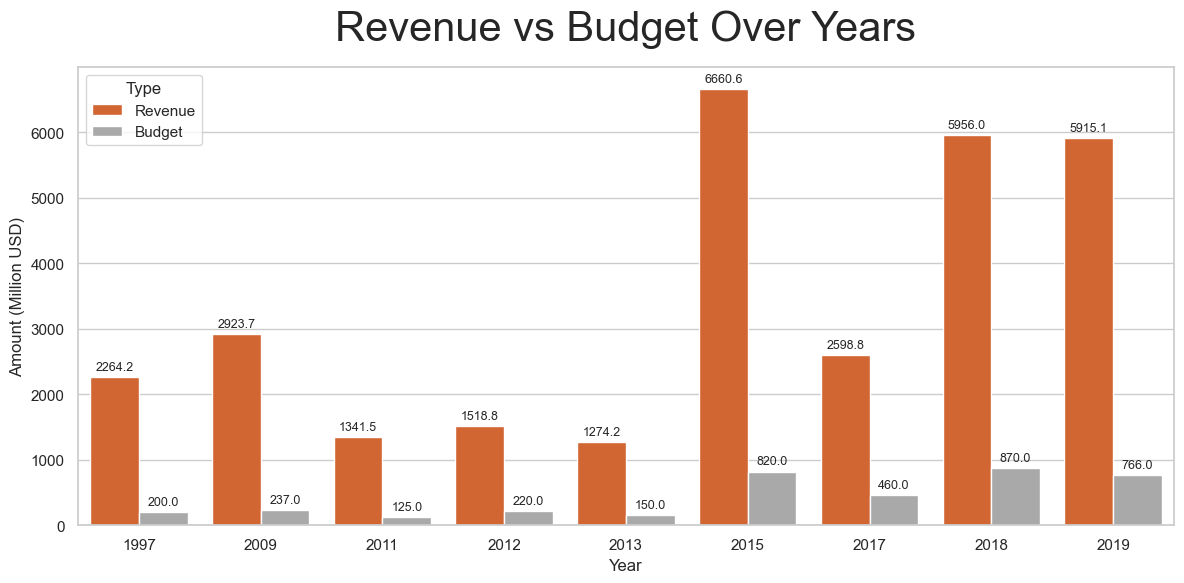

In [33]:
pdf_melted = pdf_rev_bud.melt(id_vars='year', value_vars=['Total Revenue', 'Total Budget'], 
                                             var_name='Type', value_name='Amount')
        
# Renaissance mapping for legend to match Pandas "Revenue" and "Budget"
pdf_melted['Type'] = pdf_melted['Type'].replace({'Total Revenue': 'Revenue', 'Total Budget': 'Budget'})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pdf_melted, x='year', y='Amount', hue='Type', palette=['#eb5d19', 'darkgray'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, rotation=0, fontsize=9)
    
plt.title('Revenue vs Budget Over Years', fontsize=30, pad=20)
plt.xlabel('Year')
plt.ylabel('Amount (Million USD)')
plt.legend(title='Type')
# plt.xticks(rotation=45)
plt.tight_layout()

- ROI Distribution by Genre

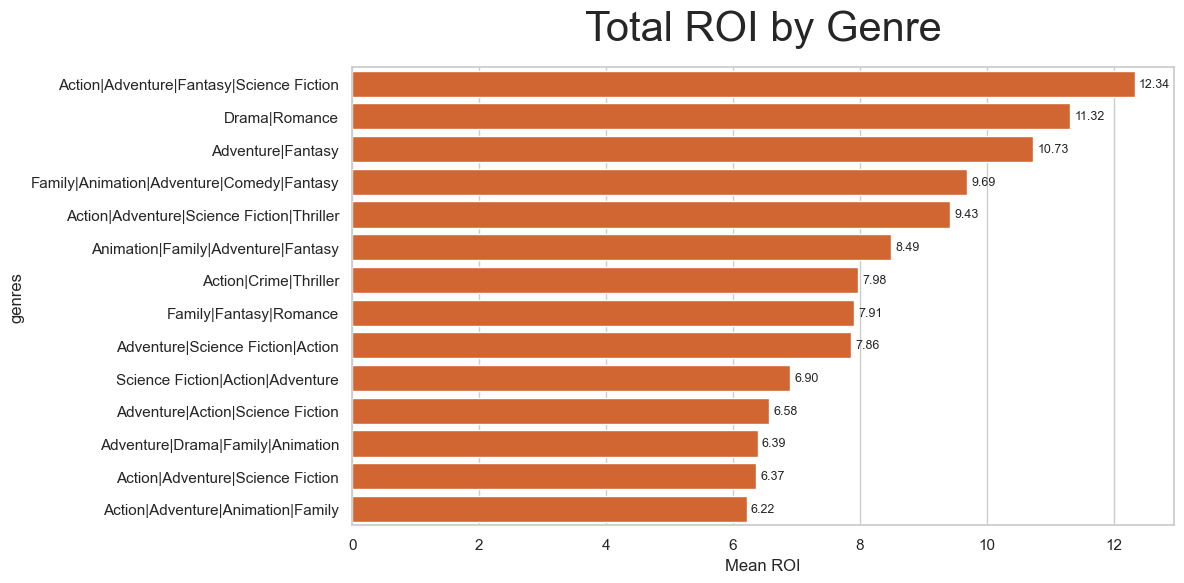

In [34]:
# Aggregate and plot
df_clean = df_clean.withColumn('roi',F.col('revenue_musd') / F.col('budget_musd'))
current_pdf_roi_genre = df_clean.groupBy("genres").agg(F.mean("roi").alias("mean_roi")).toPandas().sort_values('mean_roi', ascending=False)
plt.figure(figsize=(12, 6))
# Using seaborn barplot for consistent coloring
ax = sns.barplot(x=current_pdf_roi_genre['mean_roi'], 
                y=current_pdf_roi_genre['genres'], color='#eb5d19',
                orientation='horizontal')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, rotation=0, fontsize=9)
    
plt.title('Total ROI by Genre', fontsize=30, pad=20)
plt.xlabel('Mean ROI') # Label changed to reflect what is actually calculated (Mean vs Total in title)
plt.tight_layout()


In [35]:
plot_roi_by_genre(current_pdf_roi_genre)

Saved plots/roi_by_genre.png


- Popularity vs. Rating

In [36]:
pdf_popularity_rating = df_clean.select("popularity", "vote_average").toPandas()
plot_popularity_vs_rating(pdf_popularity_rating)

Saved plots/popularity_vs_rating.png


- Yearly Trends in Box Office Performance

In [37]:
df_yearly = df_clean.withColumn("year", F.year("release_date"))
pdf_yearly_revenue = df_yearly.groupBy("year").agg(F.sum("revenue_musd").alias("total_revenue")).orderBy("year").toPandas()
plot_yearly_trend(pdf_yearly_revenue)

Saved plots/yearly_trend.png


- Comparison of Franchise vs. Standalone Success

In [38]:
pdf_franchise_standalone = compare_franchises(df_clean).toPandas()
plot_franchise_vs_standalone(pdf_franchise_standalone)


Saved plots/franchise_vs_standalone.png


In [39]:
# Cleanup
spark.stop()